# Case Study 2: Credit Card Fraud Detection

## Objective
Detect fraudulent credit card transactions using XGBoost on a highly imbalanced dataset.

## Methodology
SMOTE is used to oversample the minority fraud class in the training data. XGBoost is then trained on the balanced training data. Different decision thresholds are evaluated using precision, recall, and F1-score. Feature importance is used to interpret the trained model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [2]:
uploaded = files.upload()

Saving Creditcard_data.csv to Creditcard_data.csv


In [3]:
df = pd.read_csv("Creditcard_data.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset shape: (772, 31)

Missing values:
0

Class distribution:
Class
0    763
1      9
Name: count, dtype: int64


In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [8]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    610
1      7
Name: count, dtype: int64

After SMOTE:
Class
0    610
1    610
Name: count, dtype: int64


In [9]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

In [10]:
model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
y_prob = model.predict_proba(X_test)[:, 1]

In [12]:
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.6536


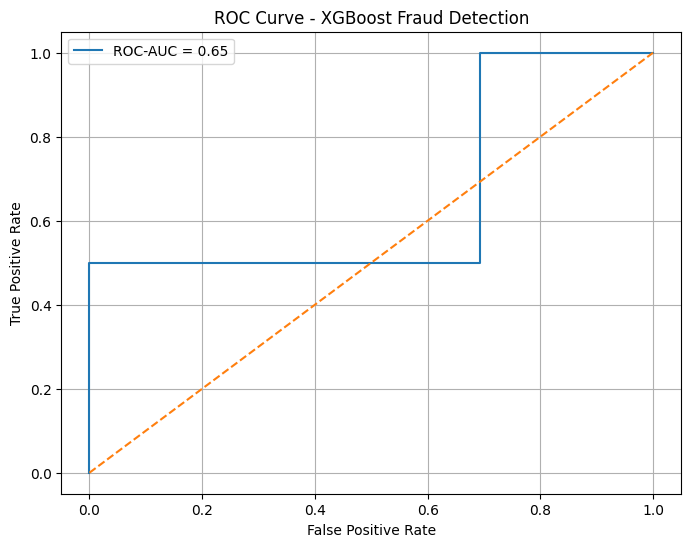

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
thresholds_to_test = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for threshold in thresholds_to_test:
    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.1,0.25,0.5,0.333333
1,0.2,0.25,0.5,0.333333
2,0.3,0.50,0.5,0.500000
3,0.4,0.50,0.5,0.500000
4,0.5,0.50,0.5,0.500000
5,0.6,1.00,0.5,0.666667
6,0.7,1.00,0.5,0.666667
7,0.8,1.00,0.5,0.666667
8,0.9,0.00,0.0,0.000000


In [15]:
best_row = threshold_results.loc[
    threshold_results["F1-Score"].idxmax()
]

best_threshold = best_row["Threshold"]

print(f"Selected Threshold: {best_threshold:.2f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1-Score: {best_row['F1-Score']:.4f}")

Selected Threshold: 0.60
Precision: 1.0000
Recall: 0.5000
F1-Score: 0.6667


In [17]:
y_pred = (y_prob >= best_threshold).astype(int)

In [18]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Confusion Matrix:
[[153   0]
 [  1   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       153
           1       1.00      0.50      0.67         2

    accuracy                           0.99       155
   macro avg       1.00      0.75      0.83       155
weighted avg       0.99      0.99      0.99       155



In [19]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Amount    0.215168
V20       0.090697
V1        0.074662
V26       0.073333
V10       0.064748
V7        0.058213
V16       0.053659
V25       0.046841
V18       0.044433
V24       0.034086
Time      0.028259
V5        0.025407
V23       0.024973
V13       0.023254
V19       0.015559
V15       0.015093
V4        0.012860
V6        0.012361
V3        0.010122
V22       0.010094
V14       0.009961
V9        0.008403
V28       0.007884
V2        0.007842
V21       0.006919
V27       0.006245
V8        0.006023
V11       0.004959
V12       0.004720
V17       0.003220
dtype: float32


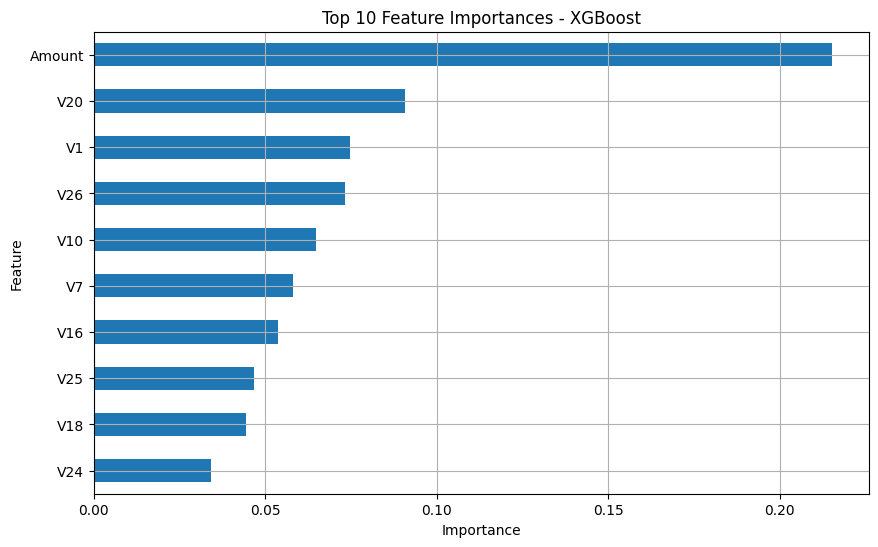

In [20]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - XGBoost")
plt.grid(True)
plt.show()